# 02 Event 1: 凱米颱風 (Gaemi) 空間預測對決

**Part A: 空間預測對決**

本 Notebook 執行凱米颱風的完整空間分析流程，包含：
- A1: Variogram 分析與擬合
- A2: 四種內插法比較 (NN, IDW, Kriging, RF)
- A3: 差異圖與不確定性分析
- A4: GeoTIFF 輸出

輸入資料：`../data/processed/gaemi_rainfall.geojson` (EPSG:3826)

CELL 1: 資料讀取與網格建立
讀取資料筆數: 117
X 範圍: 269261 ~ 346335
Y 範圍: 2557832 ~ 2763948
Z 範圍: 0.50 ~ 9.50 mm

網格資訊:
  X 網格點數: 89
  Y 網格點數: 218
  總網格點數: 19402
  解析度: 1000m

✓ CELL 1 完成

CELL 2: A1 Variogram 分析與擬合
實驗變異圖計算完成，共 6 個 lag bins

擬合參數:
  Spherical - Sill: 1.8521, Range: 68534m, Nugget: 0.6027
  Exponential - Sill: 2.4638, Range: 64381m, Nugget: 0.0000


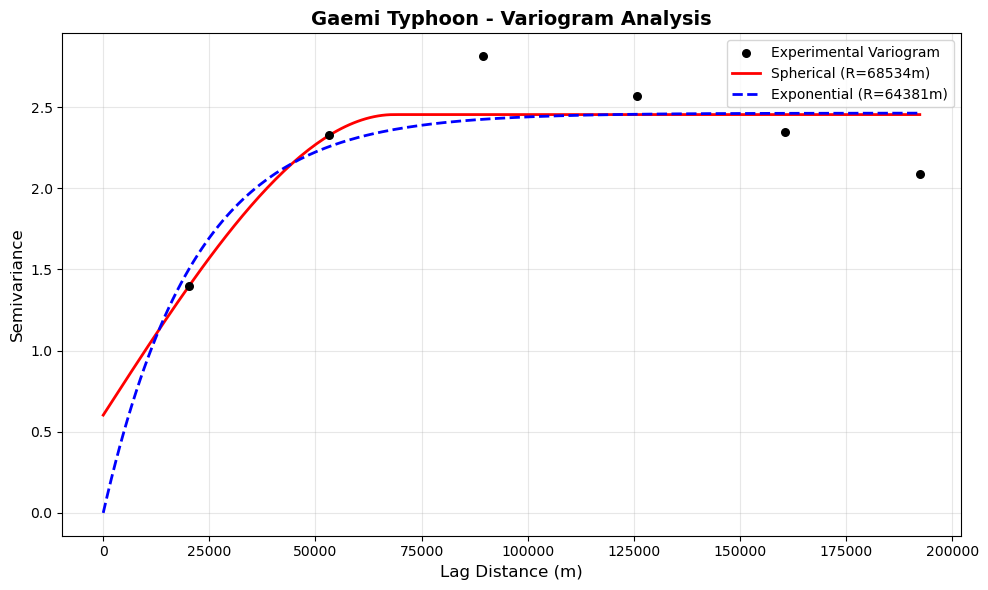


✓ 選定模型: SPHERICAL
  Sill: 1.8521
  Range: 68534 m
  Nugget: 0.6027

✓ CELL 2 完成

CELL 3: A2 四種內插法實作

[1/4] Nearest Neighbor 內插...
  完成 - 範圍: 0.50 ~ 9.50 mm

[2/4] IDW (power=2) 內插...
  完成 - 範圍: 0.51 ~ 9.35 mm

[3/4] Ordinary Kriging (spherical) 內插...
  完成 - 範圍: 0.56 ~ 5.97 mm

[4/4] Random Forest 內插...
  完成 - 範圍: 0.73 ~ 5.59 mm

繪製 2x2 比較圖...


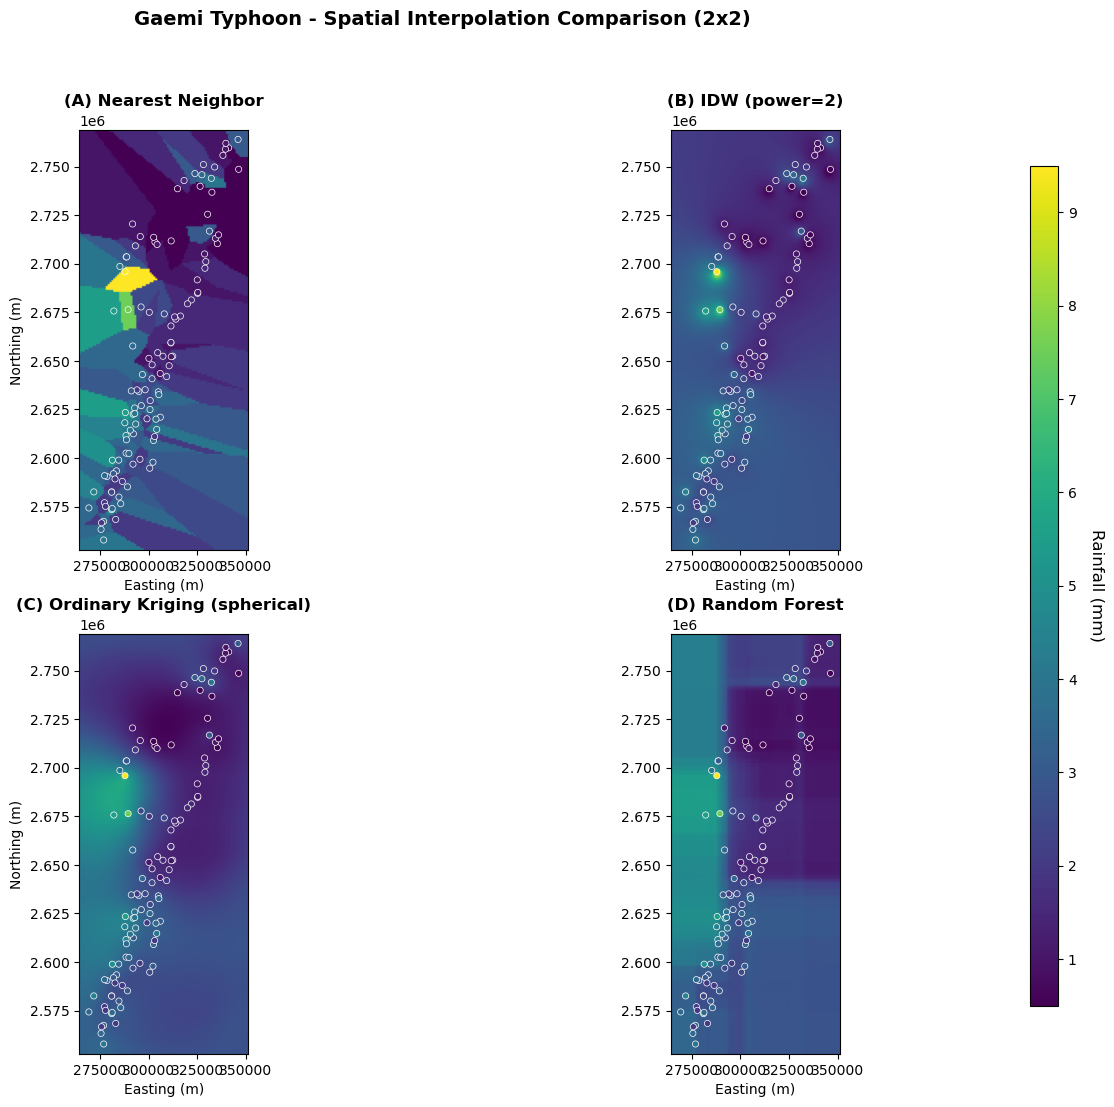

✓ 2x2 比較圖已儲存

✓ CELL 3 完成

CELL 4: A3 差異圖與不確定性分析

計算 Kriging 與 RF 差異...


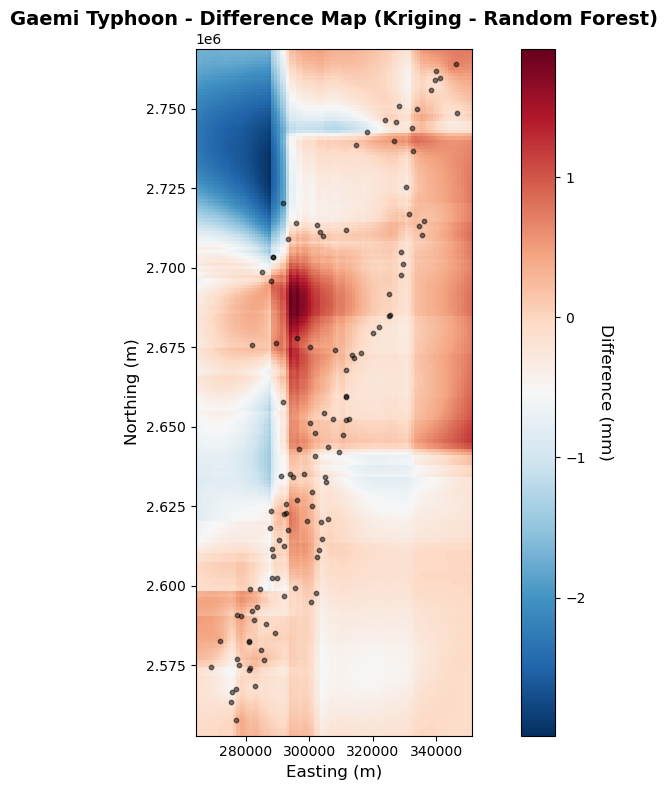

  差異範圍: -2.99 ~ 1.92 mm
  ✓ 差異圖已儲存

繪製 Kriging Sigma Map (不確定性地圖)...


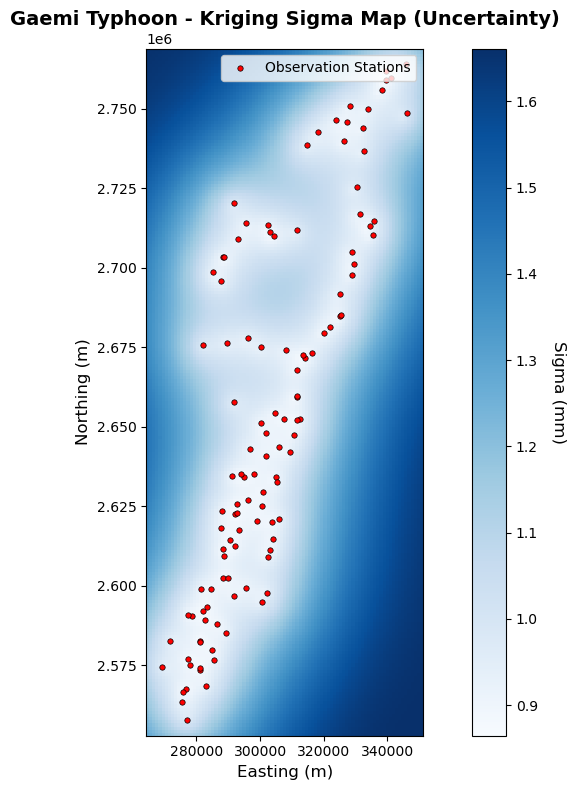

  Sigma 範圍: 0.86 ~ 1.66 mm
  ✓ Sigma Map 已儲存

✓ CELL 4 完成

CELL 5: A4 GeoTIFF 網格輸出

輸出資訊:
  CRS: EPSG:3826
  解析度: 1000m
  網格大小: 89 x 218
  原點: (264261, 2552832)

✓ 已輸出: ../outputs/geotiff\gaemi_kriging_rainfall.tif
✓ 已輸出: ../outputs/geotiff\gaemi_kriging_variance.tif
✓ 已輸出: ../outputs/geotiff\gaemi_rf_rainfall.tif

所有 GeoTIFF 輸出完成!

輸出檔案清單:
  1. ../outputs/geotiff\gaemi_kriging_rainfall.tif
  2. ../outputs/geotiff\gaemi_kriging_variance.tif
  3. ../outputs/geotiff\gaemi_rf_rainfall.tif

✓ CELL 5 完成 - 凱米颱風分析全部完成!

所有分析結果已儲存於 gaemi_results 字典中


In [1]:
# 執行完整分析腳本
%run gaemi_analysis.py

---

## 分析結果摘要

執行完成後，以下結果已產生：

### 圖表輸出 (../outputs/figures/)
- `gaemi_variogram_comparison.png` - Variogram 擬合比較圖
- `gaemi_interpolation_2x2_comparison.png` - 四種內插法 2x2 比較圖
- `gaemi_difference_kriging_rf.png` - Kriging vs RF 差異圖
- `gaemi_kriging_sigma_map.png` - Kriging 不確定性地圖

### GeoTIFF 輸出 (../outputs/geotiff/)
- `gaemi_kriging_rainfall.tif` - Kriging 降雨量預測
- `gaemi_kriging_variance.tif` - Kriging 變異數
- `gaemi_rf_rainfall.tif` - Random Forest 降雨量預測

### 主要變數
執行後可在 Notebook 中存取：`gaemi_results` 字典包含所有分析結果

In [2]:
# 檢視可用結果變數
print("可用的分析結果:")
for key in gaemi_results.keys():
    print(f"  - {key}")

可用的分析結果:
  - X
  - Y
  - Z
  - grid_x
  - grid_y
  - grid_X
  - grid_Y
  - resolution
  - buffer
  - selected_model
  - spherical_params
  - exponential_params
  - lags
  - semivariance
  - Z_nn
  - Z_idw
  - Z_kriging
  - Z_rf
  - kriging_variance
  - vmin
  - vmax
  - diff_kriging_rf
  - sigma
  - output_files
